<a href="https://colab.research.google.com/github/Antoninus90/ActividadEDA_JavierFregoso/blob/main/Actividad_1_Trabajando_con_%C3%A1rboles_de_decisi%C3%B3n_y_t%C3%A9cnicas_de_ensemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import zipfile
import os
import pandas as pd

zip_file_path = '/content/Actividad_1Inteligencia.zip'
extract_dir = '/content/'

# Check if the zip file exists before trying to extract
if os.path.exists(zip_file_path):
    print(f"Extracting {zip_file_path} to {extract_dir}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
else:
    print(f"Warning: Zip file not found at {zip_file_path}. Please ensure it's uploaded.")

# Based on the current file system, the CSV was extracted directly to /content/
csv_file_path = os.path.join(extract_dir, 'Laboratorio_dataset_car.csv')

# Check if the CSV file exists after extraction
if os.path.exists(csv_file_path):
    # Corrected: Added sep=';' to correctly parse the CSV file
    df = pd.read_csv(csv_file_path, sep=';')
    print("DataFrame loaded successfully.")
    print(df.head())
else:
    print(f"Error: CSV file not found at expected path: {csv_file_path}. Please check the zip file contents or file name.")

Extracting /content/Actividad_1Inteligencia.zip to /content/...
Extraction complete.
DataFrame loaded successfully.
  Buying Maintenance Doors Person lug_boot safety  class
0  vhigh       vhigh     2      2    small    low  unacc
1  vhigh       vhigh     2      2    small    med  unacc
2  vhigh       vhigh     2      2    small   high  unacc
3  vhigh       vhigh     2      2      med    low  unacc
4  vhigh       vhigh     2      2      med    med  unacc


In [ ]:
# Información general
df.info()

# Estadísticas básicas
df.describe()

# Distribución de clases
df['class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1750 entries, 0 to 1749
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Buying       1750 non-null   object
 1   Maintenance  1750 non-null   object
 2   Doors        1750 non-null   object
 3   Person       1750 non-null   object
 4   lug_boot     1750 non-null   object
 5   safety       1750 non-null   object
 6   class        1750 non-null   object
dtypes: object(7)
memory usage: 95.8+ KB


,count
class,
unacc,1215
acc,390
good,75
vgood,70


In [ ]:
df_encoded = pd.get_dummies(df)
df_encoded.head()

,Buying_high,Buying_low,Buying_med,Buying_vhigh,Maintenance_high,Maintenance_low,Maintenance_med,Maintenance_vhigh,Doors_2,Doors_3,...,lug_boot_big,lug_boot_med,lug_boot_small,safety_high,safety_low,safety_med,class_acc,class_good,class_unacc,class_vgood
0,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,True,False,False,False,True,False
1,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,True,False,False,True,False
2,False,False,False,True,False,False,False,True,True,False,...,False,False,True,True,False,False,False,False,True,False
3,False,False,False,True,False,False,False,True,True,False,...,False,True,False,False,True,False,False,False,True,False
4,False,False,False,True,False,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False


In [ ]:
X = df_encoded.drop(columns=[col for col in df_encoded.columns if 'class_' in col])
y = df['class']  # usamos la original (mejor práctica)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))

Accuracy Árbol: 0.96


In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

Accuracy Random Forest: 0.9514285714285714


In [ ]:
print("=== Árbol de Decisión ===")
print(classification_report(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))

=== Árbol de Decisión ===
              precision    recall  f1-score   support

         acc       0.92      0.93      0.93        89
        good       0.87      1.00      0.93        13
       unacc       0.98      0.97      0.97       235
       vgood       1.00      0.92      0.96        13

    accuracy                           0.96       350
   macro avg       0.94      0.96      0.95       350
weighted avg       0.96      0.96      0.96       350

[[ 83   1   5   0]
 [  0  13   0   0]
 [  6   1 228   0]
 [  1   0   0  12]]


In [ ]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

         acc       0.88      0.97      0.92        89
        good       0.83      0.77      0.80        13
       unacc       0.99      0.97      0.98       235
       vgood       0.91      0.77      0.83        13

    accuracy                           0.95       350
   macro avg       0.90      0.87      0.88       350
weighted avg       0.95      0.95      0.95       350

[[ 86   1   2   0]
 [  2  10   0   1]
 [  8   0 227   0]
 [  2   1   0  10]]


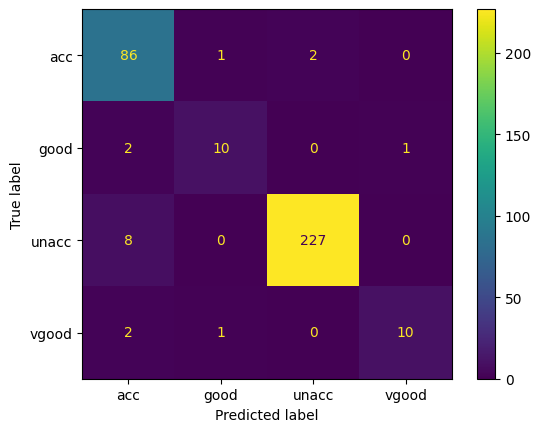

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.show()